In [1]:
!pip install givernylocal

  Using cached givernylocal-3.6.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2024.10.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached netcdf4-1.7.4-cp311-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached xarray-2025.3.1-py3-none-any.whl.metadata (12 kB)
  Using cached platformdirs-4.11.5-py3-none-any.whl.metadata (5.5 kB)
  Using cached traitlets-5.16.1-py3-none-any.whl.metadata (10 kB)
  Using cached cycler-0.12.1-py3-none-any.w

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] T

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from givernylocal.turbulence_dataset import turb_dataset
from givernylocal.turbulence_toolkit import getCutout
from scipy.ndimage import gaussian_filter

c:\personal-projects\pi-cnn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cube = turb_dataset(
    dataset_title="isotropic1024coarse",
    output_path="./jhtdb_output",
    auth_token="edu.gatech.jerrychen-6b7455a7"
)

axes_ranges = np.array([
    [1,64],
    [1,64],
    [1,64],
    [1,1]
])

strides = np.array([1,1,1,1])

cutout = getCutout(
    cube,
    var="velocity",
    xyzt_axes_ranges_original=axes_ranges,
    xyzt_strides=strides
)


-----
getCutout is processing...

total time elapsed = 4.393 seconds (0.073 minutes)

query completed successfully.
-----


In [4]:
velocity = cutout["velocity_0001"].values

speed = np.sqrt(
    velocity[:,:,:,0]**2 +
    velocity[:,:,:,1]**2 +
    velocity[:,:,:,2]**2
)

print("High-res shape:", speed.shape)

High-res shape: (64, 64, 64)


In [5]:
sigma = 1.0

speed_filtered = gaussian_filter(speed, sigma=sigma)

speed_low = speed_filtered[::2, ::2, ::2]

print("Low-res shape:", speed_low.shape)

Low-res shape: (32, 32, 32)


In [6]:
from scipy.ndimage import zoom

speed_low_up = zoom(speed_low, zoom=2, order=1)

print(speed_low_up.shape)

(64, 64, 64)


In [7]:
def build_3d_grid_graph(nx, ny, nz):
    edges = []

    def idx(i,j,k):
        return i*ny*nz + j*nz + k

    for i in range(nx):
        for j in range(ny):
            for k in range(nz):

                neighbors = [
                    (i+1,j,k),(i-1,j,k),
                    (i,j+1,k),(i,j-1,k),
                    (i,j,k+1),(i,j,k-1),
                ]

                for ni,nj,nk in neighbors:
                    if 0<=ni<nx and 0<=nj<ny and 0<=nk<nz:
                        edges.append([idx(i,j,k), idx(ni,nj,nk)])

    return torch.tensor(edges).t().contiguous()

In [8]:
nx, ny, nz = speed.shape

edge_index = build_3d_grid_graph(nx,ny,nz)

x = torch.tensor(speed_low_up.reshape(-1,1), dtype=torch.float)
y = torch.tensor(speed.reshape(-1,1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, y=y)

In [9]:
class SimpleGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1,32)
        self.conv2 = GCNConv(32,32)
        self.conv3 = GCNConv(32,1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        return x

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleGNN().to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(500):
    optimizer.zero_grad()

    pred = model(data)
    loss = loss_fn(pred, data.y)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 2.3237223625183105
20 0.8943182826042175
40 0.21864721179008484
60 0.021144011989235878
80 0.012198206037282944
100 0.010634154081344604
120 0.009254715405404568
140 0.008174855262041092
160 0.007434592582285404
180 0.006949346512556076
200 0.0066370051354169846
220 0.006448255851864815
240 0.006343927700072527
260 0.006291366647928953
280 0.006266550626605749
300 0.006252261344343424
320 0.0062448084354400635
340 0.006240730173885822
360 0.006238255649805069
380 0.006236536428332329
400 0.006235269829630852
420 0.0062343282625079155
440 0.006233593448996544
460 0.006233020685613155
480 0.0062325685285031796


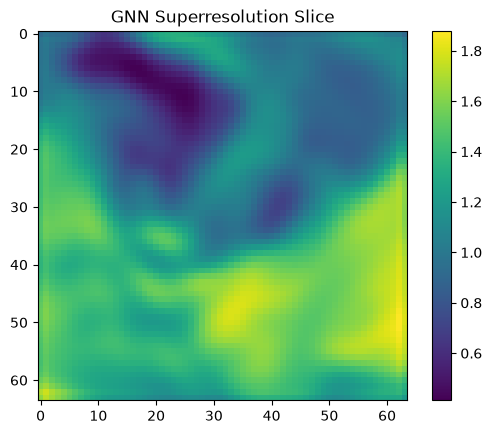

In [11]:
model.eval()

with torch.no_grad():
    pred = model(data).cpu().numpy()

pred_field = pred.reshape(nx,ny,nz)

plt.imshow(pred_field[:,:,8])
plt.title("GNN Superresolution Slice")
plt.colorbar()
plt.show()

C:\Users\Nitipon\AppData\Local\Temp\ipykernel_19672\3594353478.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


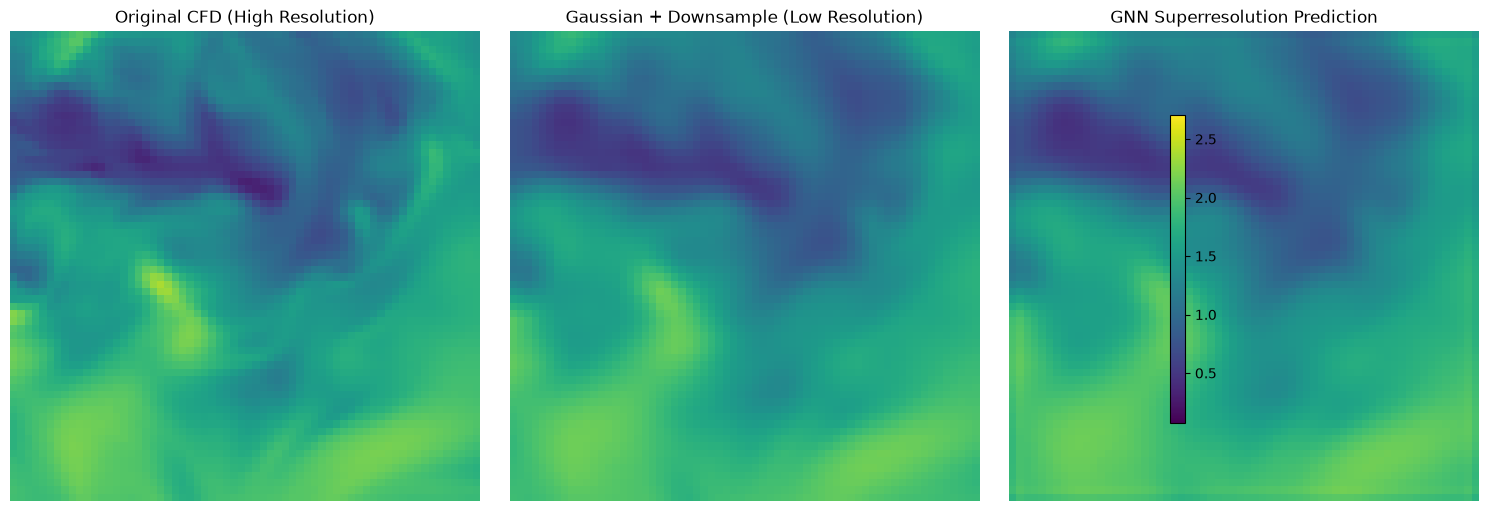

In [12]:
hr_field = speed                  # original CFD
lr_field = speed_low_up           # degraded + upsampled
gnn_field = pred_field            # prediction

slice_idx = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(15,5))

vmin = hr_field.min()
vmax = hr_field.max()

# --- Original CFD ---
im0 = axes[0].imshow(hr_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[0].set_title("Original CFD (High Resolution)")
axes[0].axis("off")

# --- Low Resolution ---
im1 = axes[1].imshow(lr_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[1].set_title("Gaussian + Downsample (Low Resolution)")
axes[1].axis("off")

# --- GNN Prediction ---
im2 = axes[2].imshow(gnn_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[2].set_title("GNN Superresolution Prediction")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

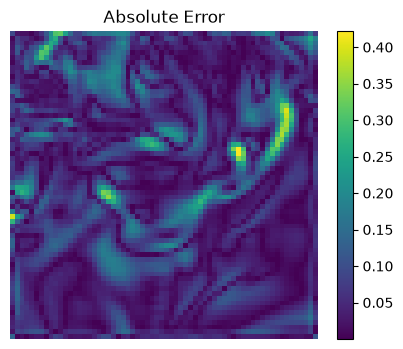

In [13]:
error = np.abs(hr_field - gnn_field)

plt.figure(figsize=(5,4))
plt.imshow(error[:,:,slice_idx])
plt.title("Absolute Error")
plt.colorbar()
plt.axis("off")
plt.show()